In [20]:
import datetime
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import scipy
from datetime import datetime, timedelta
import sys
from plotting_settings import *
sys.path.append('/glade/u/home/czarakas/coupled_PPE/code/utils')
from load_ensembles import *

In [2]:
"""def get_variable(domain='atm',var='TREFHT',h='h0',runname='COUP0000_PI_SOM'):
    fpath = '/glade/scratch/czarakas/archive/'+runname+'/'+domain+'/proc/tseries/'
    fname = fpath+'*'+h+'*.'+var+'*.nc'
    #print(fname)
    ds = xr.open_mfdataset(fname, combine='by_coords')
    return ds"""

"def get_variable(domain='atm',var='TREFHT',h='h0',runname='COUP0000_PI_SOM'):\n    fpath = '/glade/scratch/czarakas/archive/'+runname+'/'+domain+'/proc/tseries/'\n    fname = fpath+'*'+h+'*.'+var+'*.nc'\n    #print(fname)\n    ds = xr.open_mfdataset(fname, combine='by_coords')\n    return ds"

In [3]:
def get_variable(domain='atm',var='TREFHT',h='h1',runname='COUP0000_PI_SOM'):
    if var=='RESTOM':
        fsnt = get_variable(domain='atm',var='FSNT',h=h,runname=runname)
        flnt = get_variable(domain='atm',var='FLNT',h=h,runname=runname)
        ds=fsnt
        ds['RESTOM'] = fsnt.FSNT-flnt.FLNT
    else:
        fpath = '/glade/campaign/cgd/tss/people/czarakas/CoupledPPE/coupled_simulations/'+runname+'/'+domain+'/proc/tseries/month_1/'
        fname = fpath+'*'+h+'.'+var+'.*.nc'
        #print(fname)
        ds = xr.open_mfdataset(fname, combine='by_coords')
    return ds

In [4]:
ds1=xr.open_dataset('/glade/campaign/cgd/tss/people/czarakas/CoupledPPE/coupled_simulations/COUP0000_PI_SOM/atm/hist/COUP0000_PI_SOM.cam.h0.0093-01.nc')
ds2=xr.open_dataset('/glade/campaign/cgd/tss/people/czarakas/CoupledPPE/coupled_simulations/COUP0000_PI_SOM/lnd/hist/COUP0000_PI_SOM.clm2.h1.0089-02-01-00000.nc')


# Calculate area weights

In [5]:
#Atmosphere weights
weight_factor2 = ds1.gw / ds1.gw.mean(dim='lat')

#Land weights
land_area=ds2.area*ds2.landfrac
landweights = land_area/land_area.sum(dim=['lat','lon'])

#Land weights
def land_weights_region(minlat=-100,maxlat=100,ds_lnd=ds2):
    land_area=ds_lnd.area*ds_lnd.landfrac
    land_area=land_area.where(land_area.lat>=minlat).where(land_area.lat<=maxlat)
    landweights = land_area/land_area.sum(dim=['lat','lon'])
    return landweights

In [6]:
def global_avg_atm(ds, var):
    #coslat = np.cos(np.deg2rad(ds.lat))
    #atm_weights = coslat / coslat.mean(dim='lat') 
    
    atm_weights = weight_factor2 #weight_factor2/weight_factor2.mean(dim='lat') 
    
    return (ds[var]*atm_weights).mean(dim=['lat','lon'])

# Check reference case

In [7]:
def days_in_month(nyears, ds):
    '''
    returns an xr.DataArray of days per month, tiled for nyears
    '''
    days_pm  = [31,28,31,30,31,30,31,31,30,31,30,31]
    da = xr.DataArray(np.tile(days_pm,nyears),dims='time')
    da['time']=ds['time']
    return da

In [8]:
simlist=[#'COUP0000_PI_SOM'
         'COUP0001_PI_SOM_v02',#'COUP0002_PI_SOM_v02',
 'COUP0003_PI_SOM_v02',
    'COUP0004_PI_SOM_v02','COUP0005_PI_SOM_v02',
 'COUP0006_PI_SOM_v02','COUP0007_PI_SOM_v02','COUP0008_PI_SOM_v02',
 'COUP0009_PI_SOM_v02','COUP0010_PI_SOM_v02','COUP0011_PI_SOM_v02',
 'COUP0012_PI_SOM_v02',
    'COUP0013_PI_SOM_v02','COUP0014_PI_SOM_v02',
 'COUP0015_PI_SOM_v02','COUP0016_PI_SOM_v02','COUP0017_PI_SOM_v02',
 'COUP0018_PI_SOM_v02','COUP0019_PI_SOM_v02','COUP0020_PI_SOM_v02',
 'COUP0021_PI_SOM_v02','COUP0022_PI_SOM_v02','COUP0023_PI_SOM_v02',
 'COUP0024_PI_SOM_v02','COUP0025_PI_SOM_v02','COUP0026_PI_SOM_v02',
 'COUP0027_PI_SOM_v02','COUP0028_PI_SOM_v02','COUP0029_PI_SOM_v02',
 'COUP0030_PI_SOM_v02','COUP0031_PI_SOM_v02','COUP0032_PI_SOM_v02',
 'COUP0033_PI_SOM_v02','COUP0034_PI_SOM_v02','COUP0035_PI_SOM_v02',
 'COUP0036_PI_SOM_v02','COUP0037_PI_SOM_v02']

In [9]:
def weighted_temporal_mean(ds, var):
    """
    weight by days in each month
    """
    # Determine the month length
    nyears=int(np.size(ds.time)/12)
    month_length = days_in_month(nyears, ds)

    # Calculate the weights
    wgts = month_length.groupby("time.year") / month_length.groupby("time.year").sum()

    # Make sure the weights in each year add up to 1
    np.testing.assert_allclose(wgts.groupby("time.year").sum(xr.ALL_DIMS), 1.0)

    # Subset our dataset for our variable
    obs = ds[var]

    # Setup our masking for nan values
    cond = obs.isnull()
    ones = xr.where(cond, 0.0, 1.0)

    # Calculate the numerator
    obs_sum = (obs * wgts).resample(time="AS").sum(dim="time")

    # Calculate the denominator
    ones_out = (ones * wgts).resample(time="AS").sum(dim="time")

    # Return the weighted average
    return obs_sum / ones_out

In [10]:
var_to_check='RESTOM'
ds = get_variable(domain='atm',var=var_to_check,h='h0',runname='COUP0000_PI_SOM')
weight_factor = ds.gw / ds.gw.mean(dim='lat')
ds['time']=ds['time']-timedelta(days = 15)

da=ds[var_to_check]
da_annual=weighted_temporal_mean(ds,var_to_check)
da_annual_global=(da_annual*weight_factor).mean(dim=['lat','lon']).load()

In [11]:
da_annual_globals=[]

In [12]:
for i, sim in enumerate(simlist):
    ds2 = get_variable(domain='atm',var=var_to_check,h='h1',runname=sim)
    weight_factor2 = ds2.gw / ds2.gw.mean(dim='lat')
    ds2['time']=ds2['time']-timedelta(days = 15)

    da2=ds2[var_to_check]
    da_annual2=weighted_temporal_mean(ds2,var_to_check)
    da_annual_global2=(da_annual2*weight_factor2).mean(dim=['lat','lon']).load()
    da_annual_globals.append(da_annual_global2)
    #print(sim)
    print(np.nanmean(da_annual_global2[40:]))
    
    #[slope, intercept, r_value, p_value, std_err] = stats.linregress(da_annual_global2['time.year'][40:],
    #                                                             da_annual_global2[40:])
    #if p_value<=0.05:
    #    print(slope)
    #    print(p_value)

-0.14974046473221267
-0.15177153555067913
-0.16691061479603317
-0.16648845670440263
-0.14268779696427356
-0.15811483541497182
-0.15942196820787835
-0.1681942610213975
-0.15236298435624046
-0.15511579929624944
-0.17537751483534958
-0.1523544221128113
-0.17457310066321569
-0.13065564016996553
-0.17280416741599564
-0.1670691321280913
-0.16355260878194863
-0.15678084710353765
-0.14079136879353218
-0.1505547745953985
-0.16719265400075098
-0.16352926668488516
-0.1594626552525849
-0.15457663842219338
-0.15226035462823728
-0.16154488374088008
-0.1519736509655448
-0.15532625050840715
-0.15288437605035235
-0.15580655938662527
-0.14531818878632416
-0.14677770947063176
-0.16363674219176702
-0.15970011968985753
-0.15138831634627237
-0.15497658067738196


In [13]:
x=da_annual_global['time.year']
y=da_annual_global
[slope_ref, intercept_ref, r_value, p_value_ref, std_err] = stats.linregress(x,
                                                                 y)
yfit_ref=(x*slope_ref)+intercept_ref
p_value_ref

0.6406418126859954

In [14]:
da_annual_globals_avgs=[]

for i, sim in enumerate(simlist):
    da_annual_globals_avgs.append(da_annual_globals[i][40:].mean(dim='time').load().values)

0.9866726994484757
0.947723447719365
0.7161360200932633
0.7088625600731137
0.8903497099714703
0.8466662148198043
0.9359695978257293
0.8920240269587552
0.9302425081868014
0.8836339177448419
0.8267119053417045
0.6677699288782748
0.8030998509322826
0.5760866298280605
0.7128513688553606
0.8948084484547973
0.9726462540964764
0.7051620180765809
0.6273374359030939
0.6834957651242513
0.9473879568036692
0.7405278825740627
0.8763111675783389
0.8607481162144188
0.9074298716711715
0.9407487778288743
0.7475529320711396
0.8159629494226366
0.5710611461137054
0.9439634913268143
0.7690175493375203
0.8254818898398617
0.9409026048704483
0.9616436897401042
0.9582874832933301
0.8986175359976254


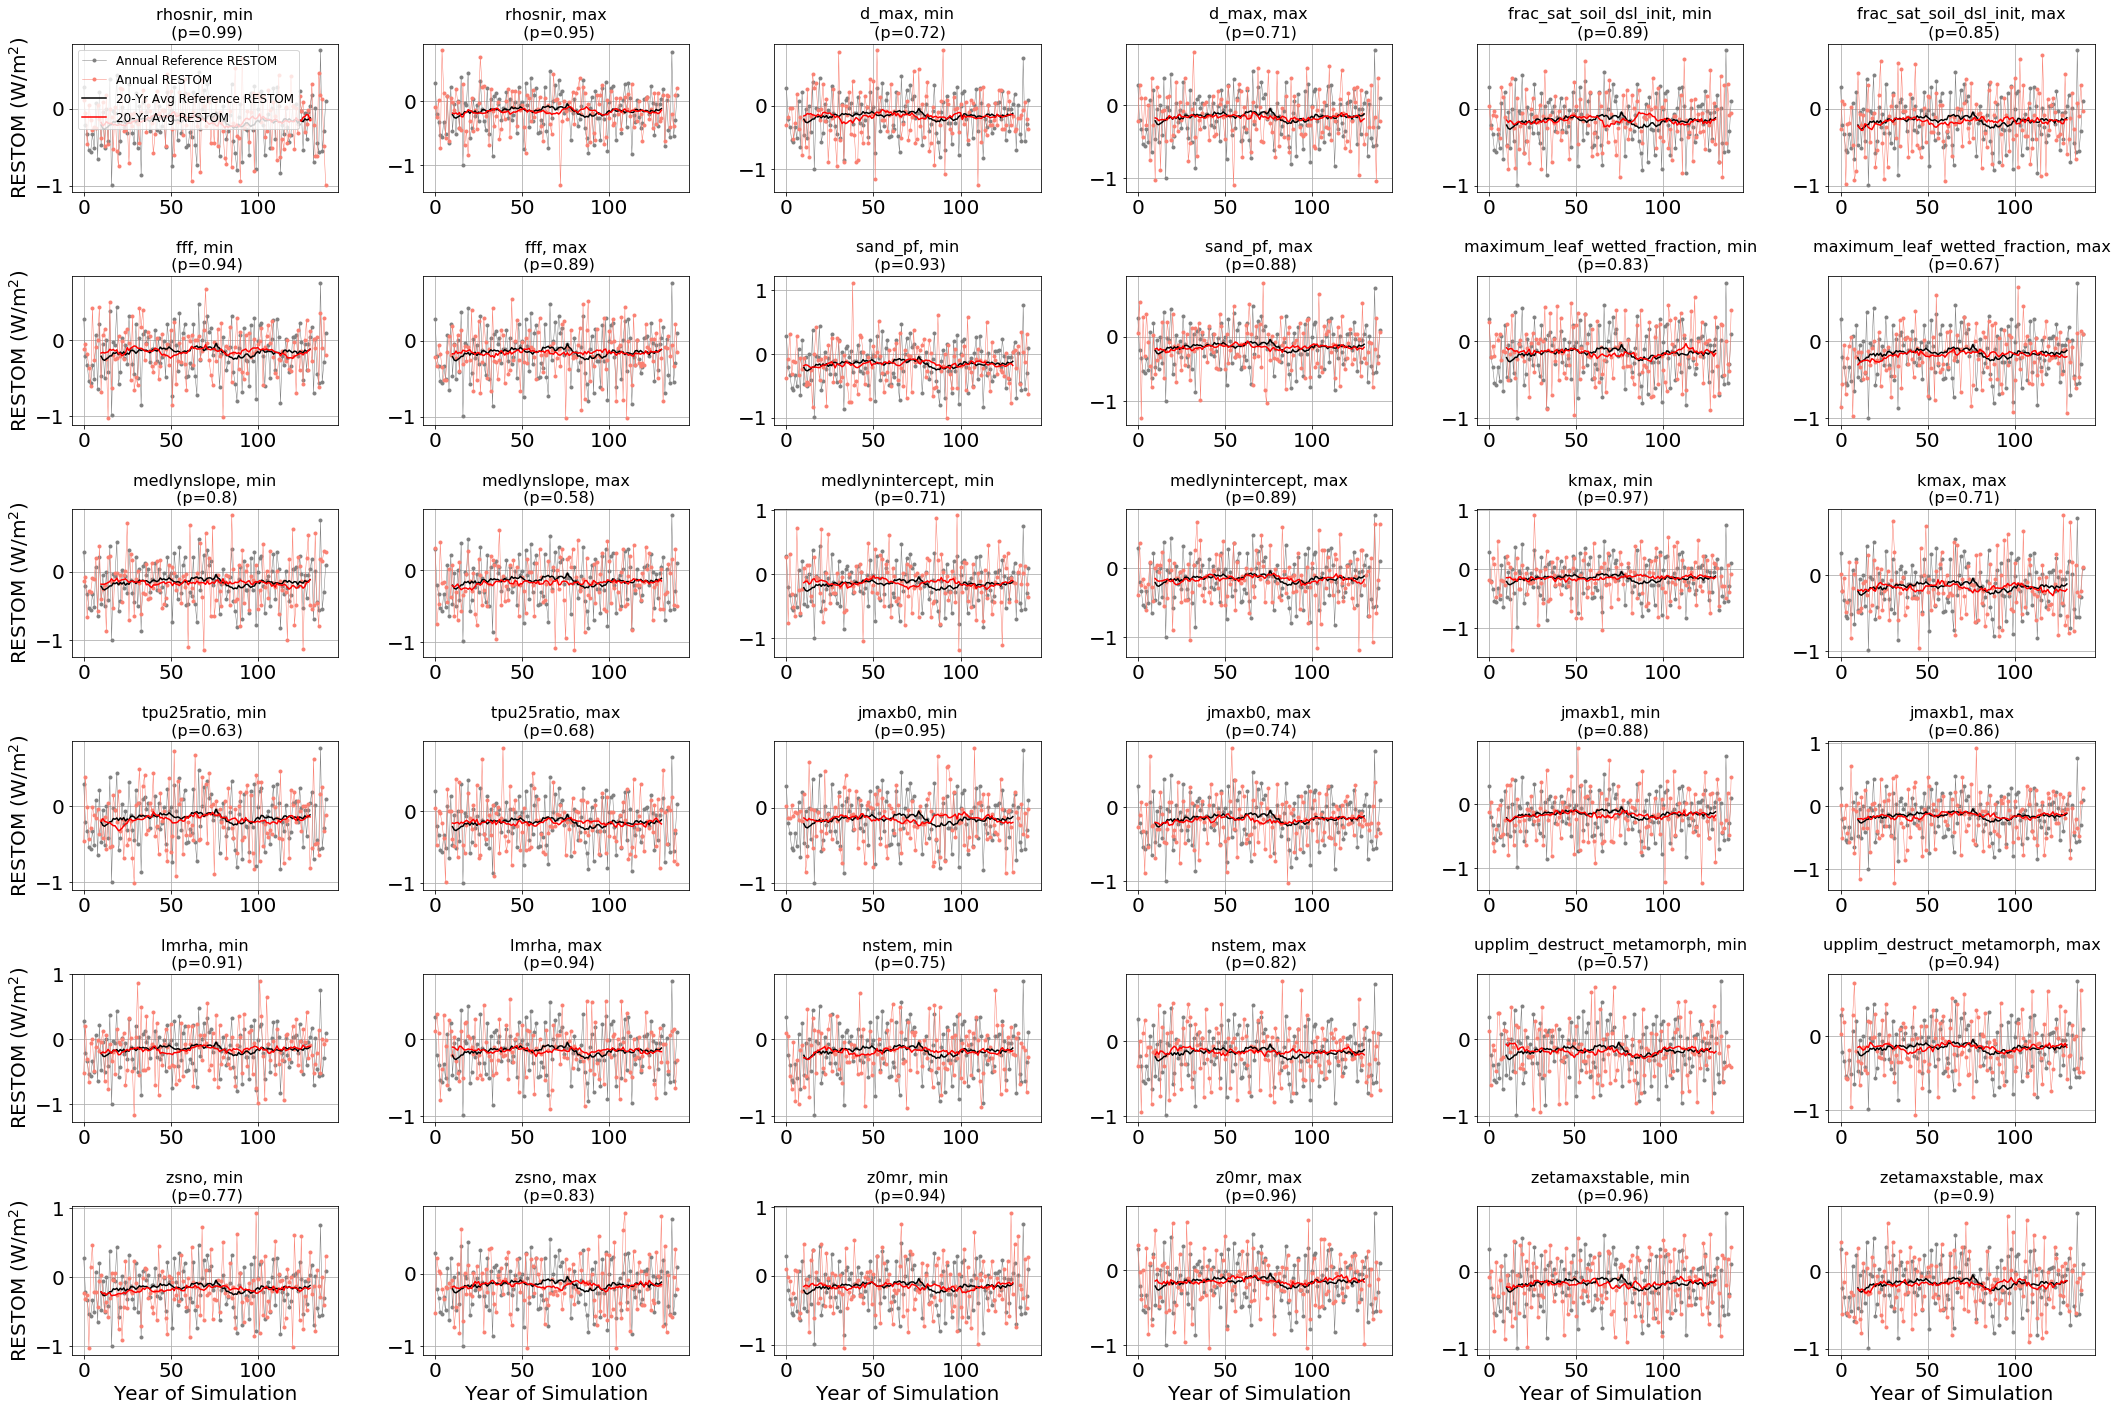

In [22]:
plt.figure(figsize=(30,20))
plt.rcParams.update({'font.size': 20})
years=np.arange(0,140)
for j,i in enumerate(int_list):
    
#for i, sim in enumerate(simlist):
    plt.subplot(6,6,j+1)
    plt.plot(da_annual_global,'.-',color='gray',linewidth=0.5, label='Annual Reference RESTOM')
    plt.plot(da_annual_globals[i],'.-',color='salmon',linewidth=0.5, label='Annual RESTOM')
    plt.plot(da_annual_global.rolling(time=20, center=True).mean(),'-k', label='20-Yr Avg Reference RESTOM')
    plt.plot(da_annual_globals[i].rolling(time=20, center=True).mean(),'-r', label='20-Yr Avg RESTOM')
    #plt.plot(years[40:140],yfit_ref[40:140],'--',color='blue',linewidth=2)
    
    [stat, p_value]=scipy.stats.ttest_ind(da_annual_global[40:],da_annual_globals[i][40:])
    
    #plt.ylim([287.55,289.35])
    print(p_value)
    if p_value<=0.05:
        plt.title(crosswalk.description.values[i]+'\n (p='+str(np.round(p_value,2))+'*)', fontsize=16)
    else:
        plt.title(crosswalk.description.values[i]+'\n (p='+str(np.round(p_value,2))+')', fontsize=16)
    plt.grid()
    if i==0:
        plt.legend(fontsize=12)
    if (j%6)==0:
        plt.ylabel('RESTOM (W/m$^2$)')
    if j>=30:
        plt.xlabel('Year of Simulation')
plt.tight_layout()
plt.savefig('../Figures/Figure_S_Minimal_RESTOM_differences.pdf')